Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

В этом задании вам так же нужно будет **ЗАПОЛНИТЬ ПРОПУСКИ** и сделать так, чтобы все работало. Ну и, конечно, написать **ВЫВОДЫ**!!!
***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from tqdm.auto import tqdm
from nltk.tokenize import WordPunctTokenizer
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

# Данные (1 pt)

В этом задании мы поработаем с чисто текстовыми данными, а именно **комментариями на YouTube** _(я искала русские датасеты, но там слишком много непотребщины, поэтому будем с английским работать)_. Про датасет можно почитать [тут](https://www.kaggle.com/datasets/surajbhandari527/100k-youtube-comments-youtube-sentiment-dataset).

In [2]:
df = pd.read_csv('100000 Youtube comments sentiment dataset.csv').dropna().reset_index(drop=True)
df = df[df['Sentiment'] != 'neutral']
print(df.shape)
df.sample(5)

(111796, 2)


,Comment,Sentiment
16007,Women like this need men like tate,Positive
111331,one of the saddest lessons of history is this ...,Negative
111955,i train a small hawk and the strength hes capa...,Positive
32046,love how i got an aspers casino add in this vi...,Positive
89987,3:41 just pause and look in the back... you’re...,Positive


В наших данных всего лишь **2 столбца**. Нетрудно догадаться, что мы займемся задачей **классификации комментариев** на негативные и позитивные. Мы не будем использовать какие-то продвинутые методы, будем просто использовать статистики по токенам.

Важно, что задача анализа текстов — это не всегда про классификацию, но и про статистики, зависимости и все такое. Иногда важно **анализировать тексты и для поиска паттернов или зависимостей**.

***

Сначала заменим `'Positive'` на `0`, `'Negative'` на `1` для удобства работы.

In [3]:
df['label'] = df['Sentiment'].map({'Positive': 1, 'Negative': 0})
df.sample(5)

,Comment,Sentiment,label
6974,Telling women to treat men like a king.... An...,Positive,1
19829,The more the women hate him\nThe more the men ...,Negative,0
2835,He sold out himself for bloody money his self ...,Negative,0
87783,Samsung tried this shit with me - I simply wen...,Negative,0
98451,i think one of the things i love the most abou...,Positive,1


Также нам важно посмотреть на **баланс классов**, а то вдруг оны несбалансированны и надо думать, что делать...

In [4]:
df['Sentiment'].value_counts()

Sentiment
Negative    55904
Positive    55892
Name: count, dtype: int64

_Ну как, сбалансированны ли данные?_ - да.

Теперь еще немного проанализируем данные: посмотрим на **длину текстов**. Это может быть очень важно для понимания: какие токенизаторы использовать, разделяются ли классы по длине.

Max 5487, Min 3, Mean 99.0685534366167


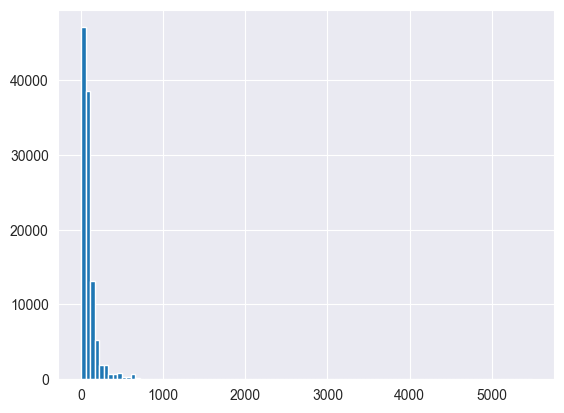

In [5]:
# длина всех текстов
lens = pd.Series(len(word) for word in df['Comment'])
print(f"Max {lens.max()}, Min {lens.min()}, Mean {lens.mean()}")

# визуализация
plt.hist(lens, bins=100)
plt.show()

Positive: Max 5487, Min 3, Mean 107.04499749516926
Negative: Max 3775, Min 4, Mean 91.09382155123068


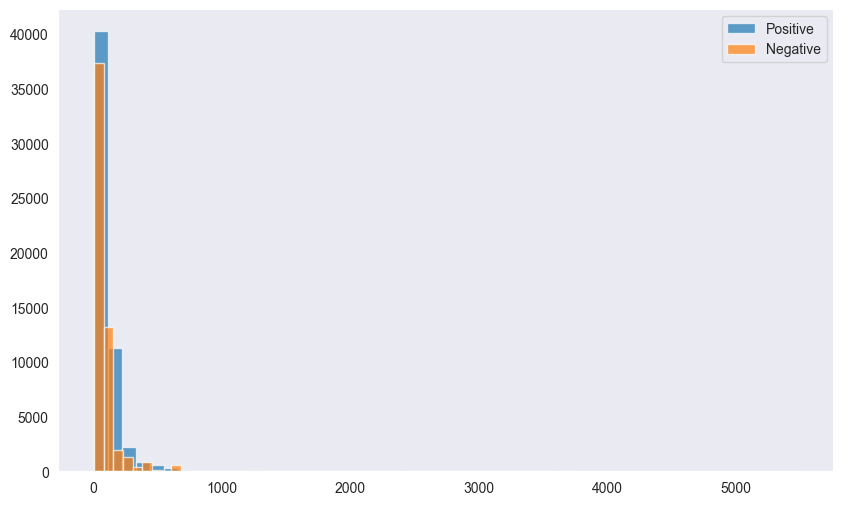

In [6]:
# длина текстов по классам
pos_comments = df.loc[df['Sentiment'] == 'Positive', 'Comment']
lens_pos = pd.Series(len(text) for text in pos_comments)
print(f"Positive: Max {lens_pos.max()}, Min {lens_pos.min()}, Mean {lens_pos.mean()}")

neg_comments = df.loc[df['Sentiment'] == 'Negative', 'Comment']
lens_neg = pd.Series(len(text) for text in neg_comments)
print(f"Negative: Max {lens_neg.max()}, Min {lens_neg.min()}, Mean {lens_neg.mean()}")

# визуализация
plt.figure(figsize=(10, 6))
plt.hist(lens_pos, bins=50, alpha=0.7, label='Positive')
plt.hist(lens_neg, bins=50, alpha=0.7, label='Negative')
plt.legend()
plt.grid()
plt.show()

**ПАРУ СЛОВ О ТОМ, ЧТО ВЫ ПОНЯЛИ ИЗ ЭТОГО**

Распределение для положительных и отрицательных классов сильно схоже. Положительные комментарии в среднем чуть длиннее, но разница слишком мала, чтобы делать выводы вроде "сильно длинный комментарий => больше шанс, что положительный". Длина комментария не является признаком.

Ну а теперь подробнее посмотрим на примеры комментариев и перейдем к токенизации

In [7]:
pos_ex = list(df[df['Sentiment'] == 'Positive'].sample(5)["Comment"])
neg_ex = list(df[df['Sentiment'] == 'Negative'].sample(5)["Comment"])

print("Positive:")
for ex in pos_ex:
    print(ex)

print("\nNegative:")
for ex in neg_ex:
    print(ex)

Positive:
Kenzie won 🥇 ⬇️
Kenzie won 🥇 ⬇️
I feel so bad for her she Doesn’t deserve to be treated like that she is so pretty
from sri lankan .
i like PRANK .
She needs to be cared by

Negative:
As a Romanian, I personally hate Andrew Tate
People who will tell all their friends to  hate James Charles
👇🏻
I remember this controversy to this day tmartns apology is the 2nd worst I’ve ever seen on YouTube
People who 

HATE HIM 
👇🏻
👇🏻
people who hate him are the ones that never take the time to listen and understand his message they are just watching clips without understanding the reality about what he says.


# Токенизация (4 pt)

**Токенизация** — это процесс **разбиения текста на меньшие единицы** (токены), которые могут быть:
- Словами (word-level): ```"I love NLP" → ["I", "love", "NLP"]```
- Символами (char-level): ```"NLP" → ["N", "L", "P"]```
- Субсловами (subword-level, BPE): ```"unbelievable" → ["un", "believ", "able"]```

**Почему это важно?**

_Размер словаря:_  
**Word**: большой словарь, много редких слов  
**Char**: маленький словарь, но очень длинные последовательности  
**BPE**: компромисс 

_OOV проблема (Out-of-Vocabulary):_  
**Word** токенизация не знает новых слов  
**Char** и **BPE** могут работать с любыми словами

_Контекст задачи:_  
Для классификации тональности часто достаточно word-токенизации  
Для работы с опечатками, сленгом — BPE лучше

***

Мы попробуем **сравнить все эти три способа** для нашей задачи, но сначала давайте их реализуем.

Для начала разделим наш датасет на обучающую и тестовую выборку. Очевидно, что **анализировать** мы будем только **тестовую выборку**.

In [8]:
train_data, test_data = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Sentiment'])
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)
print(train_data.shape)

(78257, 3)


### Word-level (0,5 pt)

Для разбиения на слова очень удобно использовать `WordPunctTokenizer` из библиотеки `nltk` (как понятно из названия, он разделяет на **слова и пунктуацию**). Давайте **разобьем комментарии на слова** и в тестовом и в обучающем наборах.

Понятно, что когда мы разбиваем на слова, для нас важен их смысл. Поэтому для того, чтобы убрать различие односмысловых токенов, написанных по-разному, **приведем все к нижнему регистру**.

In [9]:
tokenizer = WordPunctTokenizer()

# создайте столбец с токенами уровня слов
train_data['tokens_word'] = train_data['Comment'].str.lower().apply(tokenizer.tokenize)
test_data['tokens_word'] = test_data['Comment'].str.lower().apply(tokenizer.tokenize)

In [10]:
assert train_data['tokens_word'][666] == ['i', 'just', 'want', 'to', 'give', 'her', 'a', 'hug', '😭']
assert train_data['tokens_word'][101][1] == '’'
assert train_data['tokens_word'][42][-1] == '👇🏻'

assert test_data['tokens_word'][321] == ['she', 'needs', 'to', 'be', 'cared', 'by']
assert test_data['tokens_word'][666][10] == 'pathological'
assert test_data['tokens_word'][42][-1] == '😭'

In [11]:
train_data.sample(3)

,Comment,Sentiment,label,tokens_word
41011,felt like this was a tech startup more than a ...,Positive,1,"[felt, like, this, was, a, tech, startup, more..."
77906,Team ban James charles\n👇🏻,Negative,0,"[team, ban, james, charles, 👇🏻]"
73033,To be treated like a king you should act like ...,Positive,1,"[to, be, treated, like, a, king, you, should, ..."


Давайте посчитаем **количество токенов** в этом случае

In [12]:
# посчитайте количество уникальных токенов
vocab_word_count = train_data['tokens_word'].explode().nunique()
vocab_word_count

25529

### Char-level (0,5 pt)

В этом случае можно вообще обойтись просто удобствами языка и просто **пройтись по элементам строки**. Давайте также создадим и столбец для такой токенизации.

Тут уже **не будем приводить к нижнему регистру**, так как смысл все равно не важен, а информацию потерять можем.

In [13]:
# создайте столбец с токенами уровня символов
train_data['tokens_char'] = train_data['Comment'].astype(str)
test_data['tokens_char'] = test_data['Comment'].astype(str)

In [14]:
assert len(train_data['tokens_char'][666]) == 30
assert train_data['tokens_char'][101][1] == 't'
assert train_data['tokens_char'][42][-1] == '🏻'

assert len(test_data['tokens_char'][321]) == 24
assert test_data['tokens_char'][666][10] == 'e'
assert test_data['tokens_char'][42][-1] == '😭'

И тут посчитаем **количество токенов**.

In [15]:
vocab_char_count = train_data['tokens_char'].nunique()
vocab_char_count

13356

### BPE, ну или что-то очень похожее (2,5 pt)

**Byte-Pair Encoding (BPE)** — алгоритм субсловной токенизации, который:
1. начинает с _посимвольного разбиения_,
2. итеративно _объединяет самые частые пары_ токенов,
3. останавливается при достижении _нужного размера словаря_.

Вам нужно самим реализовать такой токенайзер (упрощенную версию), заполнив пропуски.

In [16]:
class BPETokenizer:
    
    def __init__(self, vocab_size=1000):

        self.vocab_size = vocab_size
        self.vocab = {}  # токен -> индекс
        self.merges = {}  # список слияний (пара токенов -> новый токен)
        self._cache = {} # для ускорения токенизации
        
    def _get_stats(self, tokens):
        # посчитайте частоту каждой пары соседних токенов
        counts = defaultdict(int)
        for i in range(len(tokens) - 1):
            pair = (tokens[i], tokens[i+1])
            counts[pair] += 1
        return counts

    def _merge(self, tokens, pair, new_token):
        # замените все вхождения пары на один новый токен
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        return new_tokens

    def train(self, text):
        # посчитайте частоту слов, разделяя их пробелами
        words = text.split()
        # представьте каждое слово как список символов с пробелом в конце
        word_freqs = Counter([" ".join(list(word)) + " </w>" for word in words])
        
        # создайте начальный словарь из уникальных символов
        unique_chars = set()
        for word in word_freqs:
            for char in word.split():
                unique_chars.add(char)
        
        self.vocab = {char: i for i, char in enumerate(sorted(unique_chars))}
        num_merges = self.vocab_size - len(self.vocab)
    
        for i in tqdm(range(num_merges)):
            # посчитайте пары только внутри уникальных слов, умножая на их частоту
            pairs = defaultdict(int)
            for word, freq in word_freqs.items():
                symbols = word.split()
                for j in range(len(symbols) - 1):
                    pair = (symbols[j], symbols[j+1])
                    pairs[pair] += freq
            
            if not pairs:
                break
                
            best_pair = max(pairs, key=pairs.get)
            new_token = "".join(best_pair)
            
            self.merges[best_pair] = new_token
            self.vocab[new_token] = len(self.vocab)
            
            # обновите словарь частот слов (замена пары на новый токен)
            new_word_freqs = {}
            pair_str = " ".join(best_pair)
            replacement = new_token
            for word, freq in word_freqs.items():
                new_word = word.replace(pair_str, replacement)
                new_word_freqs[new_word] = freq
            word_freqs = new_word_freqs

    def tokenize(self, text):
        words = text.split()
        result = []
        
        for word in words:
            if word not in self._cache:
                word_tokens = list(word) + ["</w>"]
                for pair, new_token in self.merges.items():
                    word_tokens = self._merge(word_tokens, pair, new_token)
                self._cache[word] = word_tokens
            
            result.extend(self._cache[word])
            
        return result

Применим эту токенизацию также как и прошлые

In [17]:
bpe_tokenizer = BPETokenizer(vocab_size=5000)
full_text = " ".join(train_data['Comment'].astype(str).str.lower())
bpe_tokenizer.train(full_text)

train_data['tokens_bpe'] = [bpe_tokenizer.tokenize(text) for text in tqdm(train_data['Comment'].astype(str).str.lower())]
test_data['tokens_bpe'] = [bpe_tokenizer.tokenize(text) for text in tqdm(test_data['Comment'].astype(str).str.lower())]
# сделал так, потому что иначе падало с AttributeError: 'generator' object has no attribute 'split' при передаче генератора. 
# возможно, я просто не понял вашу затею, что вы хотели поставить вместо точек. Ну, работает как надо, и ладно.

  0%|          | 0/4239 [00:00<?, ?it/s]

  0%|          | 0/78257 [00:00<?, ?it/s]

  0%|          | 0/33539 [00:00<?, ?it/s]

In [18]:
assert train_data['tokens_bpe'][4] == ['i</w>', 'miss</w>', 'pri', 'me</w>', 'h3h3</w>']
assert train_data['tokens_bpe'][101][1] == 'wi'
assert train_data['tokens_bpe'][42][-1] == '👇🏻</w>'

assert test_data['tokens_bpe'][2] == ['kenzie</w>', 'won</w>', '🥇</w>', '⬇️</w>']
assert test_data['tokens_bpe'][666][10] == 'nu'
assert test_data['tokens_bpe'][42][-1] == '😭</w>'

Мы задавали количество токенов в токенайзере, но это не значит, что у нас будет столько же в данных.

In [19]:
vocab_bpe_count = train_data['tokens_bpe'].explode().nunique()
vocab_bpe_count

2724

### Сравнение (0,5 pt)

Теперь давайте **сравним** количество токенов и **длины предложений** в разных токенизациях. Создадим для этого сравнительную табличку.

In [20]:
def stats(tokens_series):
    lengths = tokens_series.str.len()
    unique_tokens = set()
    for tokens in tokens_series:
        unique_tokens.update(tokens)
    vocab_size = len(unique_tokens)
    return {
        'vocab_size': vocab_size,
        'mean': lengths.mean(),
        'median': lengths.median(),
        'min': lengths.min(),
        'max': lengths.max()
    }

stats_word = stats(train_data['tokens_word'])
stats_char = stats(train_data['tokens_char'])
stats_bpe = stats(train_data['tokens_bpe'])

stats_comparison = pd.DataFrame({
    'Метод': ['Word (nltk)', 'Char', 'BPE'],
    'Размер словаря': [
        stats_word['vocab_size'],
        stats_char['vocab_size'],
        stats_bpe['vocab_size']
    ],
    'Средняя длина': [
        stats_word['mean'],
        stats_char['mean'],
        stats_bpe['mean']
    ],
    'Медиана': [
        stats_word['median'],
        stats_char['median'],
        stats_bpe['median']
    ],
    'Мин': [
        stats_word['min'],
        stats_char['min'],
        stats_bpe['min']
    ],
    'Макс': [
        stats_word['max'],
        stats_char['max'],
        stats_bpe['max']
    ]
}, index=[1, 2, 3])

stats_comparison

,Метод,Размер словаря,Средняя длина,Медиана,Мин,Макс
1,Word (nltk),25529,21.039012,14.0,1,666
2,Char,791,98.741991,67.0,3,3634
3,BPE,2724,37.246738,25.0,1,1424


**ВАШИ ПАРУ СЛОВ ПРО СРАВНЕНИЕ РАЗНЫХ СПОСОБОВ**

Word имеет самый большой словарь, генерирует самые короткие последовательности. Поскольку слова сохраняются целиком, словарь огромен из-за морфологии. 
Char - наоборот: минимальный словарь, но самые длинные последовательности. Тяжело в вычислениях, зато решает проблему OOV. 
BPE: умеренный словарь, умеренная длина последовательностей.

# Признаки и анализ (4 pt)

После того, как мы токенизировали наши тексты, хочется **проанализировать частоты встречаемости токенов** и выбрать те токены, которые несут нам какую-то важную информацию.

### Самые частые токены (1,5 pt)

Для начала для каждого вида токенизации посмотрим на:
1. **топ 10 частых токенов** _(можете и вообще все частоты еще посмотреть)_,
2. **топ 10 частых токенов по видам комментариев**.

Такой анализ может нам показать, есть ли вообще отличия во встречаемости в разных классах.

In [21]:
# реализуйте функцию для подсчета встречаемости токенов (сколько раз встречается каждый токен)
def count_tokens(column):
    all_tokens_pos = []
    all_tokens_neg = []
    
    for idx, row in train_data.iterrows():
        if row['Sentiment'] == 'Positive':
            all_tokens_pos.extend(row[column])
        else:
            all_tokens_neg.extend(row[column])
    
    freq_pos = Counter(all_tokens_pos)
    freq_neg = Counter(all_tokens_neg)
    freq_all = Counter(all_tokens_pos + all_tokens_neg)

    return freq_all, freq_pos, freq_neg

# сделайте визуализацию топа по частоте
def freq_visualization(top_all, top_pos, top_neg, ton_count=10):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    tokens_all, counts_all = zip(*top_all)
    sns.barplot(x=counts_all, y=tokens_all, ax=axes[0])
    axes[0].set_title(f'Top {ton_count} tokens (all)')
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('Tokens')
    axes[0].tick_params(axis='y', labelsize=10)
    
    tokens_pos, counts_pos = zip(*top_pos)
    sns.barplot(x=counts_pos, y=tokens_pos, ax=axes[1])
    axes[1].set_title(f'Top {ton_count} tokens (Positive)')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Tokens')
    axes[1].tick_params(axis='y', labelsize=10)
    
    tokens_neg, counts_neg = zip(*top_neg)
    sns.barplot(x=counts_neg, y=tokens_neg, ax=axes[2])
    axes[2].set_title(f'Top {ton_count} tokens (Negative)')
    axes[2].set_xlabel('Frequency')
    axes[2].set_ylabel('Tokens')
    axes[2].tick_params(axis='y', labelsize=10)
    
    plt.tight_layout()
    plt.show()

[('i', 24856), ('the', 24083), ('to', 21380), ('a', 18168), ('and', 17527), ('.', 14967), ('is', 11387), ('that', 11383), ('this', 11360), ('you', 11222)] [('the', 22020), ('i', 19743), ('to', 16268), ('.', 14112), ('who', 13464), ('and', 12978), ('people', 12750), ('that', 12071), ('james', 11893), ('a', 11440)] [('the', 46103), ('i', 44599), ('to', 37648), ('and', 30505), ('a', 29608), ('.', 29079), ('that', 23454), ('this', 22470), ('is', 20040), ('you', 19008)]


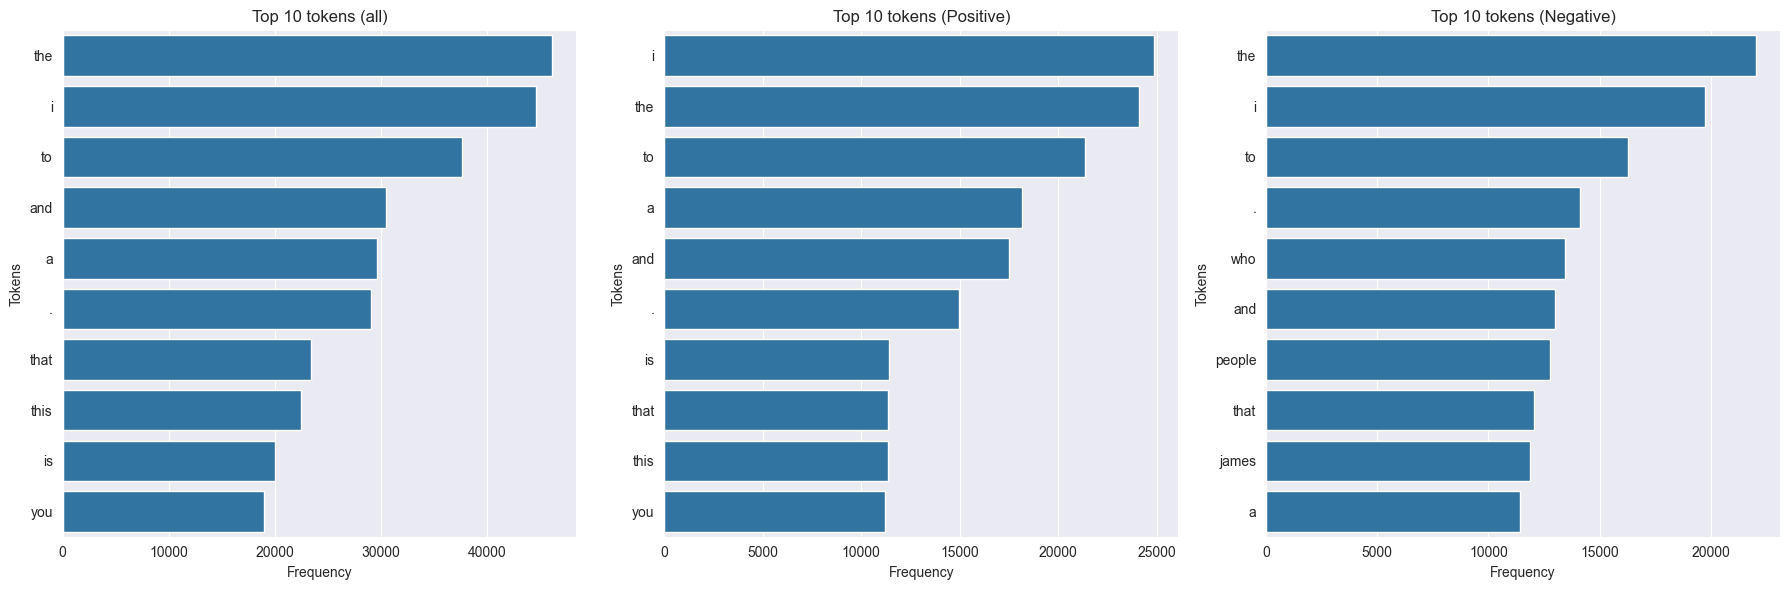

In [22]:
# Word-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_word') # это на самом деле не частоты

top_pos = [(token, count) for token, count in freq_pos.most_common(10)]
top_neg = [(token, count) for token, count in freq_neg.most_common(10)]
top_all = [(token, count) for token, count in freq_all.most_common(10)]
print(top_pos, top_neg, top_all)
freq_visualization(top_all, top_pos, top_neg)

[(' ', 755846), ('e', 395715), ('t', 276609), ('a', 247363), ('o', 243199), ('i', 220680), ('n', 209161), ('s', 205543), ('h', 177776), ('r', 152525)] [(' ', 656428), ('e', 361185), ('a', 232258), ('t', 232063), ('o', 193148), ('s', 189652), ('h', 181440), ('i', 158348), ('n', 153271), ('r', 136991)] [(' ', 1412274), ('e', 756900), ('t', 508672), ('a', 479621), ('o', 436347), ('s', 395195), ('i', 379028), ('n', 362432), ('h', 359216), ('r', 289516)]


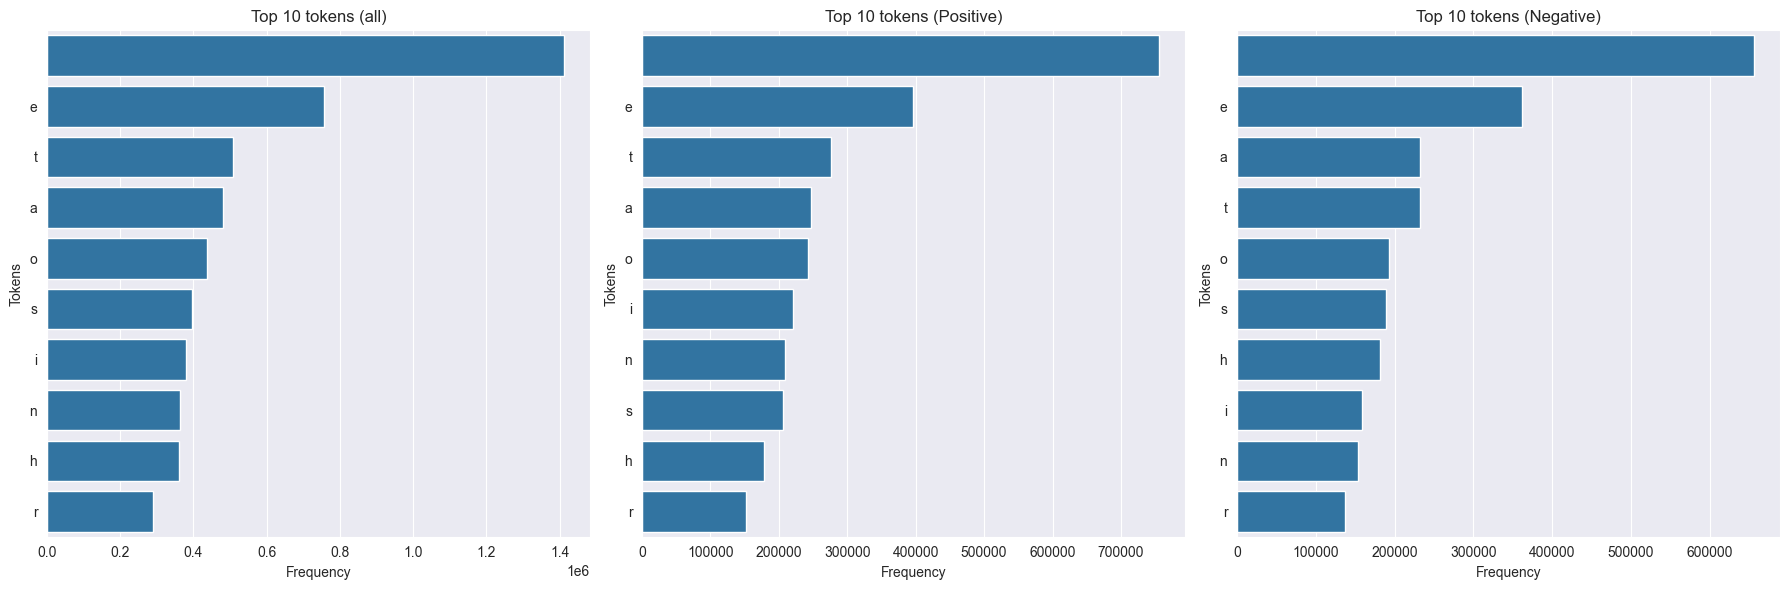

In [23]:
# Char-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_char')

top_pos = [(token, count) for token, count in freq_pos.most_common(10)]
top_neg = [(token, count) for token, count in freq_neg.most_common(10)]
top_all = [(token, count) for token, count in freq_all.most_common(10)]
print(top_pos, top_neg, top_all)
freq_visualization(top_all, top_pos, top_neg)

[('t</w>', 49647), ('e</w>', 41827), ('th', 29860), ('the</w>', 23993), ('a', 23346), ('i</w>', 22818), ('to</w>', 21704), ('s', 21468), ('a</w>', 20502), ('d', 18978)] [('e</w>', 42756), ('t</w>', 37318), ('ha', 30994), ('t', 27509), ('th', 23150), ('the</w>', 21937), ('c', 20115), ('r', 17865), ('s', 17755), ('i</w>', 17631)] [('t</w>', 86965), ('e</w>', 84583), ('th', 53010), ('t', 46342), ('the</w>', 45930), ('ha', 42008), ('i</w>', 40449), ('a', 39765), ('s', 39223), ('to</w>', 37857)]


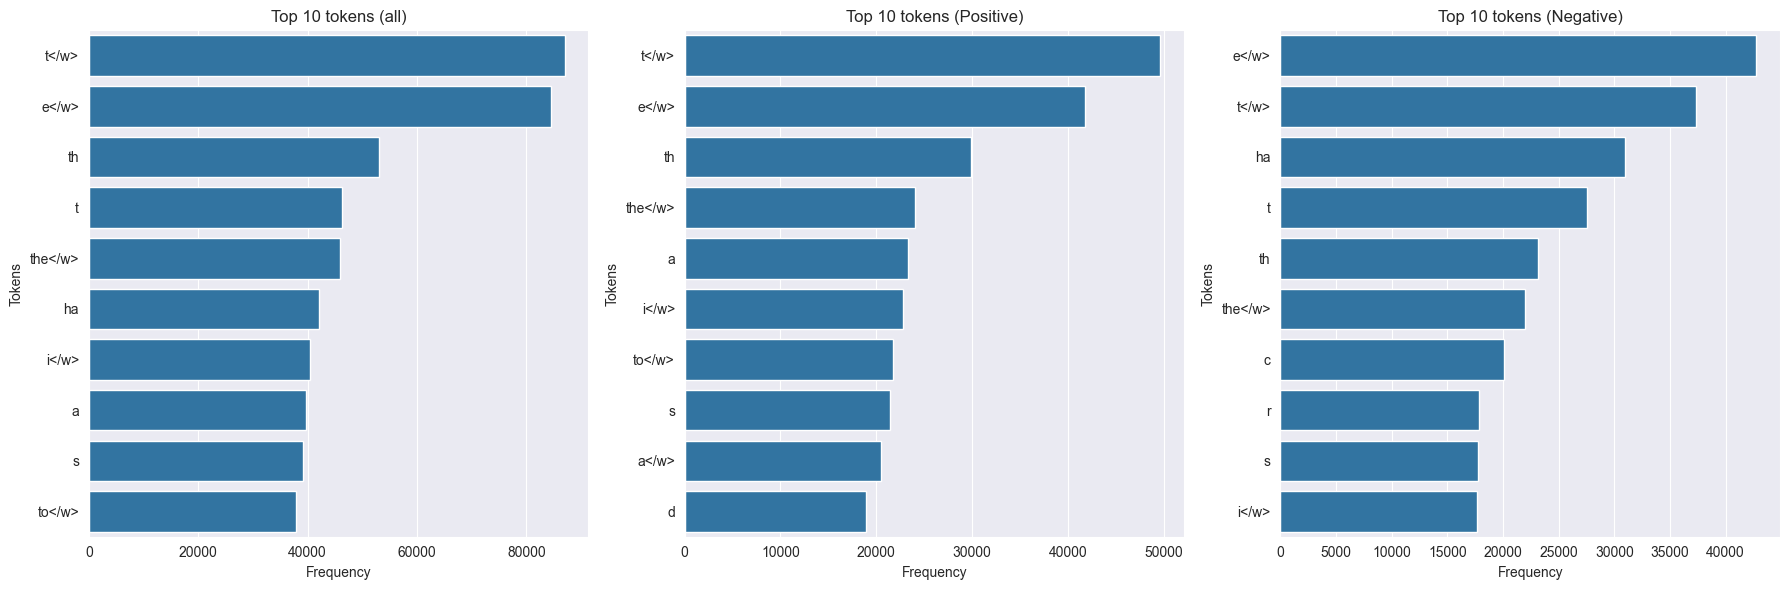

In [24]:
# BPE

freq_all, freq_pos, freq_neg = count_tokens('tokens_bpe')

top_pos = [(token, count) for token, count in freq_pos.most_common(10)]
top_neg = [(token, count) for token, count in freq_neg.most_common(10)]
top_all = [(token, count) for token, count in freq_all.most_common(10)]
print(top_pos, top_neg, top_all)
freq_visualization(top_all, top_pos, top_neg)

**ВАШИ ВЫВОДЫ**

Чего-то, сигнализирующего об эмоциях, в топ-10 нет. Word показывает больше различий между классами по топ-10. Char, логично, почти не различает классы. BPE даёт средний результат: есть различия в подсловах, но интерпретировать их сложнее.

***
Знать самые частые токены — это конечно хорошо, но кажется, что нам важнее знать те токены, у которых сильно **отличается частота в зависимости от класса**. Давайте для каждого вида токенизации найдем **топ 15** таких токенов.

In [25]:
# Word-level
freq_all, freq_pos, freq_neg = count_tokens('tokens_word')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_word = {}

for token in set(freq_pos.keys()) | set(freq_neg.keys()):
    p_pos = freq_pos.get(token, 0) / total_pos
    p_neg = freq_neg.get(token, 0) / total_neg
    diffs_word[token] = abs(p_pos - p_neg)

# Аналогично для char и bpe с созданием diffs_char и diffs_bpe

top_diff_word = sorted(diffs_word.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_word:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: james | Разница: 0.01405
Токен: who | Разница: 0.01149
Токен: charles | Разница: 0.01129
Токен: people | Разница: 0.01091
Токен: hate | Разница: 0.01057
Токен: 👇 | Разница: 0.00647
Токен: bad | Разница: 0.00621
Токен: her | Разница: 0.00596
Токен: a | Разница: 0.00546
Токен: ' | Разница: 0.00543
Токен: him | Разница: 0.00519
Токен: already | Разница: 0.00465
Токен: " | Разница: 0.00448
Токен: hated | Разница: 0.00412
Токен: love | Разница: 0.00403


In [26]:
# Char-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_char')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_char = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())

for token in all_unique_tokens:
    p_pos = freq_pos.get(token, 0) / total_pos
    p_neg = freq_neg.get(token, 0) / total_neg
    diffs_char[token] = abs(p_pos - p_neg)

top_diff_char = sorted(diffs_char.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_char:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: i | Разница: 0.00860
Токен: h | Разница: 0.00819
Токен: n | Разница: 0.00725
Токен: e | Разница: 0.00625
Токен: a | Разница: 0.00572
Токен: g | Разница: 0.00495
Токен: o | Разница: 0.00425
Токен: v | Разница: 0.00404
Токен: 
 | Разница: 0.00393
Токен: s | Разница: 0.00382
Токен: 👇 | Разница: 0.00305
Токен: c | Разница: 0.00295
Токен: k | Разница: 0.00286
Токен: J | Разница: 0.00283
Токен:   | Разница: 0.00255


In [27]:
# BPE

freq_all, freq_pos, freq_neg = count_tokens('tokens_bpe')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_bpe = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())

for token in all_unique_tokens:
    p_pos = freq_pos.get(token, 0) / total_pos
    p_neg = freq_neg.get(token, 0) / total_neg
    diffs_bpe[token] = abs(p_pos - p_neg)

top_diff_bpe = sorted(diffs_bpe.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_bpe:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: ha | Разница: 0.01643
Токен: t | Разница: 0.00888
Токен: james</w> | Разница: 0.00755
Токен: es</w> | Разница: 0.00678
Токен: who</w> | Разница: 0.00657
Токен: c | Разница: 0.00640
Токен: r | Разница: 0.00610
Токен: e</w> | Разница: 0.00590
Токен: people</w> | Разница: 0.00584
Токен: g | Разница: 0.00410
Токен: re | Разница: 0.00378
Токен: 👇</w> | Разница: 0.00374
Токен: ee | Разница: 0.00351
Токен: ba | Разница: 0.00336
Токен: l | Разница: 0.00335


**ВАША ПАРА СЛОВ ПРО ЭТО**

Word: Разница между классами невелика (максимум ~0.014). Эмоциональная окраска формируется не отдельными словами, а их сочетаниями. Тем не менее, слова "hate",
"love" уже заметны в топе.

Char: Почти не разделяет классы, потому что отдельный символ не несёт смысловой нагрузки.

BPE: Токен "ha" выделяется сильнее всего — видимо, потому, что он в сильных "hate" и "hated".

### Создание признаков (1,5 pt)

Теперь, когда мы знаем частоты токенов, можно создавать признаки для классификации. Давайте сделаем **пять разных обучающих наборов** (учтите, что вам еще также менять и тест, поэтому лучше сделать функцию):
1. (1 - 3) присутствуют или нет **топ-10 слов по каждой токенизации отдельно**,
2. **объединенный топ** по всем токенизациям,
3. ваши признаки, которые вы считаете, что хорошо себя покажут.

То есть мы хотим превратить наши предложения в **таблицы единиц и нулей**: встречаются ли токены, или нет.

In [28]:
def one_tok_features(data, top_diff, column_name):
    target_tokens = [token for token, _ in top_diff]
    cols = {token: data[column_name].apply(lambda tokens_list, t=token: 1 if t in tokens_list else 0)for token in target_tokens}
    
    return pd.concat([data[['label']], pd.DataFrame(cols, index=data.index)], axis=1)

#пришлось сделать так, чтобы warning`ов не было

In [29]:
# Word-level
# закидываем не топ-15 слов, а топ-100
top_diff_word = sorted(diffs_word.items(), key=lambda x: x[1], reverse=True)[:100]
train_data_word_ohe = one_tok_features(train_data, top_diff_word, 'tokens_word')
test_data_word_ohe = one_tok_features(test_data, top_diff_word, 'tokens_word')

# Char-level
# char особой информации не несут, пускай остаётся top-15
top_diff_char = sorted(diffs_char.items(), key=lambda x: x[1], reverse=True)[:15]
train_data_char_ohe = one_tok_features(train_data, top_diff_char, 'tokens_char')
test_data_char_ohe = one_tok_features(test_data, top_diff_char, 'tokens_char')

# BPE
#bpe хочется попоробовать top-50
top_diff_bpe = sorted(diffs_bpe.items(), key=lambda x: x[1], reverse=True)[:50]
train_data_bpe_ohe = one_tok_features(train_data, top_diff_bpe, 'tokens_bpe')
test_data_bpe_ohe = one_tok_features(test_data, top_diff_bpe, 'tokens_bpe')

In [30]:
def all_tok_features(data, top_diffs, column_names):
      cols = {}
      for col, diff_list in zip(column_names, top_diffs):
          tokens = [token for token, _ in diff_list]
          for token in tokens:
              feature_name = f"{col.split('_')[1]}_{token}"
              cols[feature_name] = data[col].apply(lambda tokens_list, t=token: 1 if t in tokens_list else 0)

      return pd.concat([data[['label']], pd.DataFrame(cols, index=data.index)], axis=1)


In [31]:
# All

train_data_all_ohe = all_tok_features(train_data,
                                      [top_diff_word, top_diff_char, top_diff_bpe],
                                      ['tokens_word', 'tokens_char', 'tokens_bpe'])
test_data_all_ohe = all_tok_features(test_data,
                                      [top_diff_word, top_diff_char, top_diff_bpe],
                                      ['tokens_word', 'tokens_char', 'tokens_bpe'])

In [32]:
def my_features(data):
    new_data = pd.DataFrame({'label': data['label']})
    
    # Количество восклицательных знаков 
    new_data['exclamation_count'] = data['Comment'].astype(str).str.count(r'!')
    
    # Количество вопросительных знаков
    new_data['question_count'] = data['Comment'].astype(str).str.count(r'\?')
    
    # Количество слов капсом
    new_data['upper_words_count'] = data['Comment'].astype(str).apply(lambda x: sum(1 for word in x.split() if word.isupper() and len(word) > 1))
    
    # Наличие конкретных слов из топа 
    hate_words = ['hate', 'hated', 'bad']
    love_words = ['love', 'good', 'great']
    
    new_data['has_hate'] = data['Comment'].astype(str).str.lower().apply(lambda x: any(word in x for word in hate_words)).astype(int)
    new_data['has_love'] = data['Comment'].astype(str).str.lower().apply(lambda x: any(word in x for word in love_words)).astype(int)
    
    # Средняя длина слова
    new_data['avg_word_len'] = data['Comment'].astype(str).apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)    
    
    return new_data

In [33]:
train_data_my_features = my_features(train_data)
test_data_my_features = my_features(test_data)

### Разделимость классов (1 pt)

Прежде чем обучать, давайте посмотрим на то, как **признаки классы разделяют**. Возможно, что-то совсем не работает)

Для этого воспользуемся уже известным нам `PCA` и визуализируем все в 2D.

In [34]:
from sklearn.preprocessing import StandardScaler
def visualize_umap(df, title="UMAP"):
    X = df.drop('label', axis=1)
    y = df['label']
    X = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=42)
    pca_data = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=y, alpha=0.7)
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

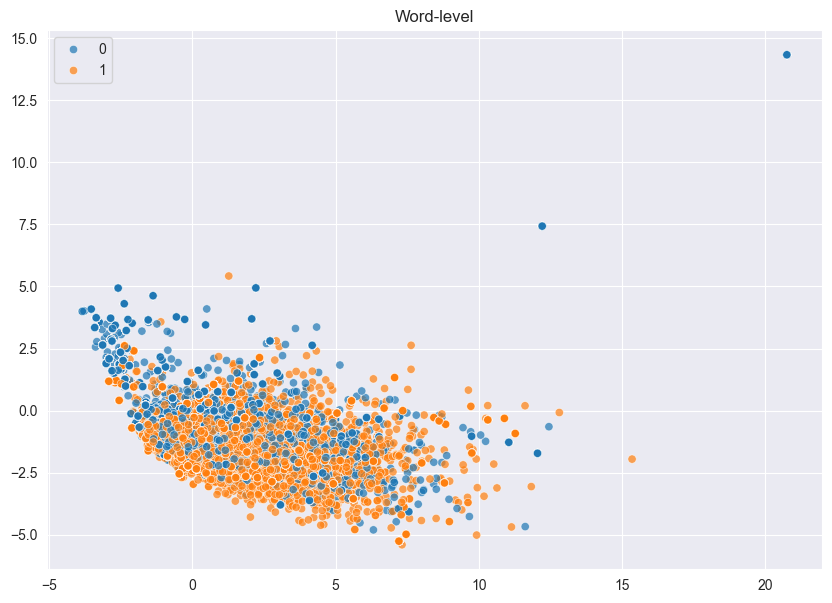

In [35]:
visualize_umap(train_data_word_ohe, "Word-level")

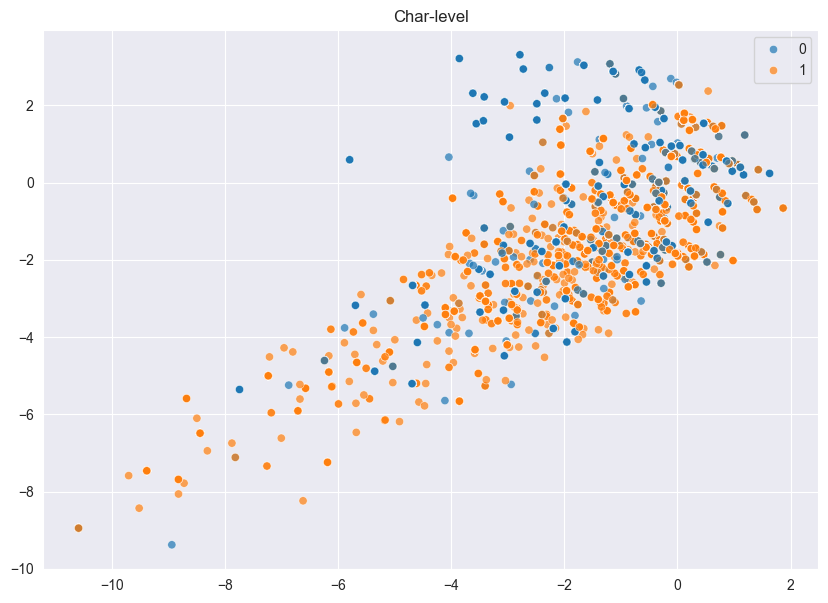

In [36]:
visualize_umap(train_data_char_ohe, "Char-level")

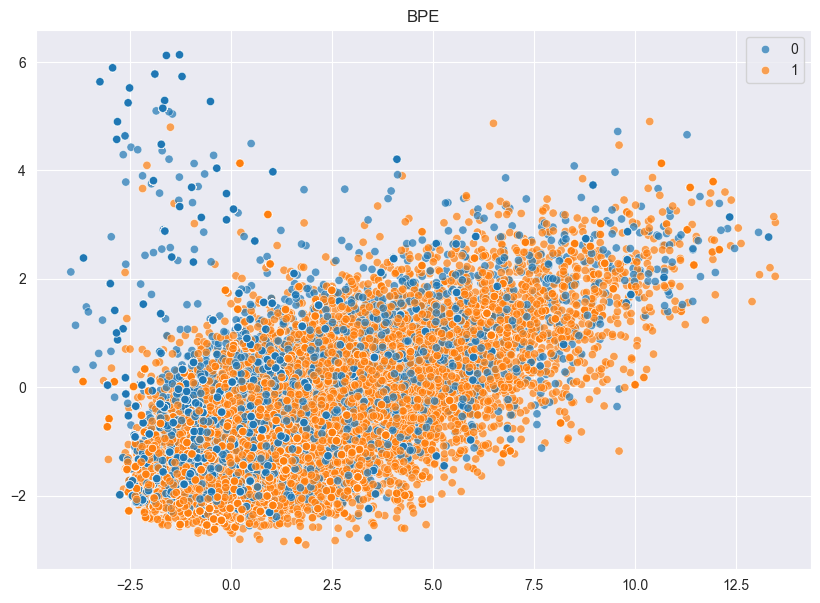

In [37]:
visualize_umap(train_data_bpe_ohe, "BPE")

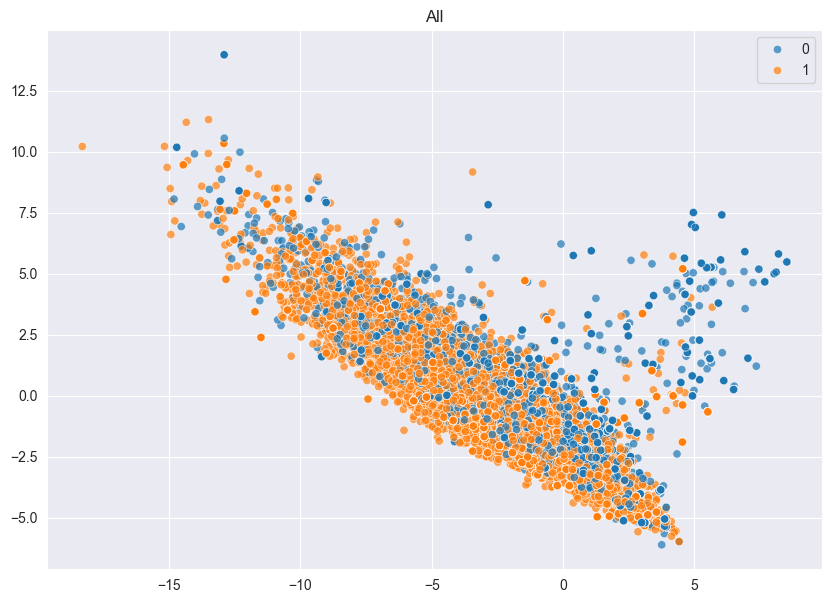

In [38]:
visualize_umap(train_data_all_ohe, "All")

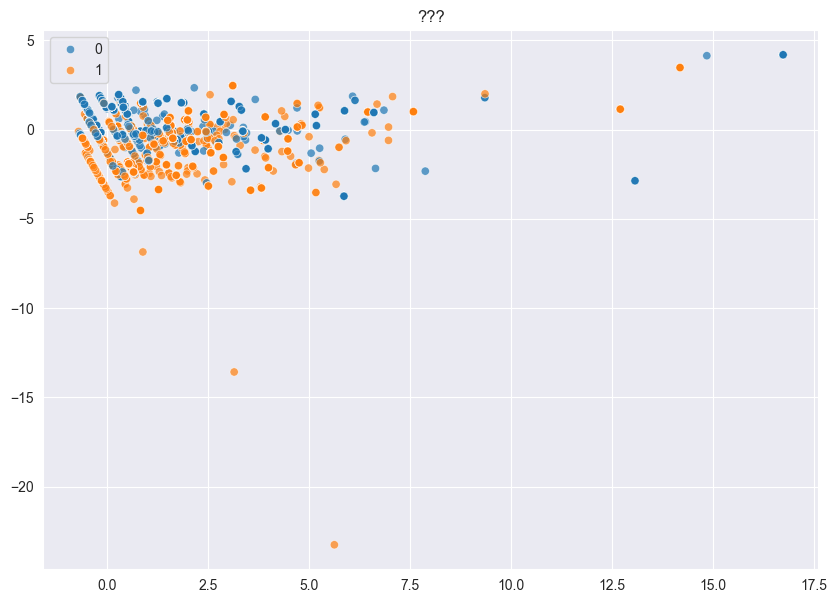

In [39]:
visualize_umap(train_data_my_features, "???")

**ВАШИ ВЫВОДЫ**

Ни один из наборов не даёт линейно разделимых классов в пространстве первых двух компонент.

При увеличении числа признаков (Word топ-100 вместо 10) классы всё равно сильно перекрываются, линейно разделить не получается

> Может быть слишком мало признаков? Вернитесь назад и попробуйте использовать больше признаков, что-то изменится?

# Модели и интерпретация (1 pt)

Теперь перейдем к обучению, обучим простенькую люгистическую регрессию и посмотрим на метрики. Будем использовать `ROC-AUC`.

In [40]:
def train_and_predict(model, train_data, test_data, title):
    
    train_X = train_data.drop('label', axis=1)
    train_y = train_data['label']
    test_X = test_data.drop('label', axis=1)
    test_y = test_data['label']

    model.fit(train_X, train_y)
    
    for name, X, y in [
        ('train', train_X, train_y),
        ('test ', test_X, test_y)
    ]:
        proba = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, proba)
        plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))
    
    plt.plot([0, 1], [0, 1], '--', color='black',)
    plt.legend(fontsize='large')
    plt.title(title)
    plt.grid()
    
    test_accuracy = (model.predict(test_X) == test_y).mean()
    print(f"Model accuracy: {test_accuracy:.3f}")

Model accuracy: 0.851


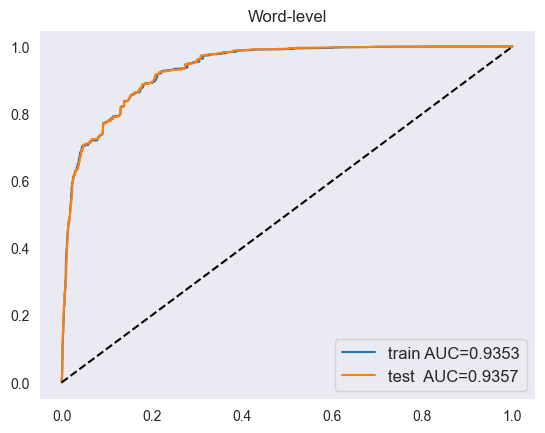

In [41]:
# Word-level

word_model = LogisticRegression(C=1.0) # можно поиграться с параметром C
train_and_predict(word_model, train_data_word_ohe, test_data_word_ohe, "Word-level")

Model accuracy: 0.732


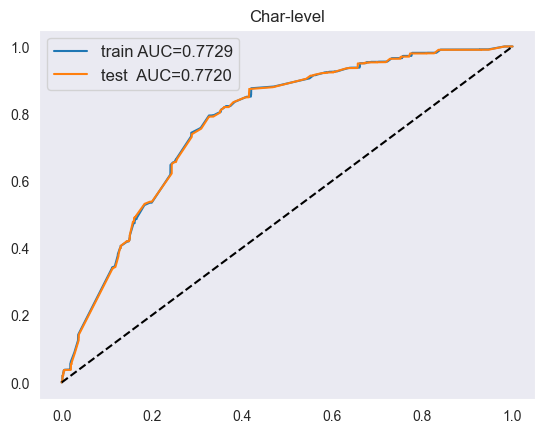

In [42]:
# Char-level

char_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(char_model, train_data_char_ohe, test_data_char_ohe, "Char-level")

Model accuracy: 0.789


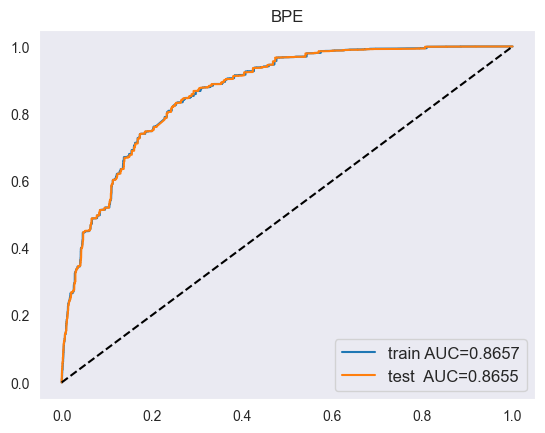

In [43]:
# BPE

bpe_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(bpe_model, train_data_bpe_ohe, test_data_bpe_ohe, "BPE")

Model accuracy: 0.877


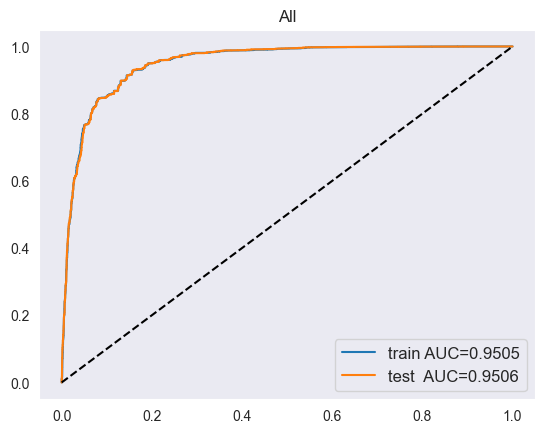

In [44]:
# All

all_model = LogisticRegression(C=0.25) # можно поиграться с параметром C
train_and_predict(all_model, train_data_all_ohe, test_data_all_ohe, "All")

In [45]:
# Решил сделать что-то типа координатного спуска по vocab_size, kw, kb, чтобы найти оптимальные параметры
# BPE обучается только 1 раз на каждый размер

train_val, val = train_test_split(train_data, test_size=0.2, random_state=42, stratify=train_data["Sentiment"])
train_val = train_val.reset_index(drop=True)
val = val.reset_index(drop=True)

def compute_diffs(data, col):
    pos = data.loc[data["Sentiment"] == "Positive", col]
    neg = data.loc[data["Sentiment"] == "Negative", col]
    fp = Counter(t for ts in pos for t in ts)
    fn = Counter(t for ts in neg for t in ts)
    tp, tn = sum(fp.values()), sum(fn.values())
    return {t: abs(fp.get(t,0)/tp - fn.get(t,0)/tn) for t in set(fp) | set(fn)}

def ohe(data, diffs, k, col, drop_label=False):
    top = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:k]
    f = one_tok_features(data, top, col)
    return f.drop("label", axis=1) if drop_label else f

def score(vs, kw, kb):
    tv_bpe, vv_bpe, db = bpe_cache[vs]
    X_tr = pd.concat([ohe(train_val, dw, kw, "tokens_word"),
                      ohe(tv_bpe, db, kb, "tokens_bpe", drop_label=True),
                      train_my], axis=1)
    X_va = pd.concat([ohe(val, dw, kw, "tokens_word"),
                      ohe(vv_bpe, db, kb, "tokens_bpe", drop_label=True),
                      val_my], axis=1)
    
    m = LogisticRegression(max_iter=1000)
    m.fit(X_tr.drop("label", axis=1), X_tr["label"])
    
    return roc_auc_score(X_va["label"], m.predict_proba(X_va.drop("label", axis=1))[:, 1])

dw = compute_diffs(train_val, "tokens_word")
train_my = my_features(train_val).drop("label", axis=1)
val_my = my_features(val).drop("label", axis=1)

vocab_sizes = [i for i in range (500, 1500, 50)]
k_word_vals = [i for i in range (50, 500, 50)]
k_bpe_vals  = [i for i in range(50, 300, 50)]

# Обучаю BPE один раз для каждого vocab_size
bpe_cache = {}
for vs in tqdm(vocab_sizes, desc="BPE"):
    tok = BPETokenizer(vocab_size=vs)
    tok.train(" ".join(train_val["Comment"].astype(str).str.lower()))
    tv = train_val.assign(tokens_bpe=[tok.tokenize(t) for t in train_val["Comment"].astype(str).str.lower()])
    vv = val.assign(tokens_bpe=[tok.tokenize(t) for t in val["Comment"].astype(str).str.lower()])
    bpe_cache[vs] = (tv, vv, compute_diffs(tv, "tokens_bpe"))

best_vs = vocab_sizes[len(vocab_sizes)//2]
best_kw = k_word_vals[len(k_word_vals)//2]
best_kb = k_bpe_vals[len(k_bpe_vals)//2]

for param, vals in [("vocab_size", vocab_sizes), ("kw", k_word_vals), ("kb", k_bpe_vals)]:
    best_auc, best_val = -1, None
    for v in tqdm(vals, desc=param):
        vs, kw, kb = best_vs, best_kw, best_kb
        
        if param == "vocab_size": vs = v
        elif param == "kw":         kw = v
        else:                        kb = v
        
        auc = score(vs, kw, kb)
        
        if auc > best_auc:
            best_auc, best_val = auc, v
            
    if param == "vocab_size": best_vs = best_val
    elif param == "kw": best_kw = best_val
    else:               best_kb = best_val
    
    print(f"{param}: best={best_val}, AUC={best_auc:.4f}")

print(f"Итог: vocab_size={best_vs}, kw={best_kw}, kb={best_kb}")


BPE:   0%|          | 0/20 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

vocab_size: best=800, AUC=0.9813


kw:   0%|          | 0/9 [00:00<?, ?it/s]

kw: best=450, AUC=0.9868


kb:   0%|          | 0/5 [00:00<?, ?it/s]

kb: best=250, AUC=0.9875
Итог: vocab_size=800, kw=450, kb=250


  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/78257 [00:00<?, ?it/s]

  0%|          | 0/33539 [00:00<?, ?it/s]

Model accuracy: 0.949


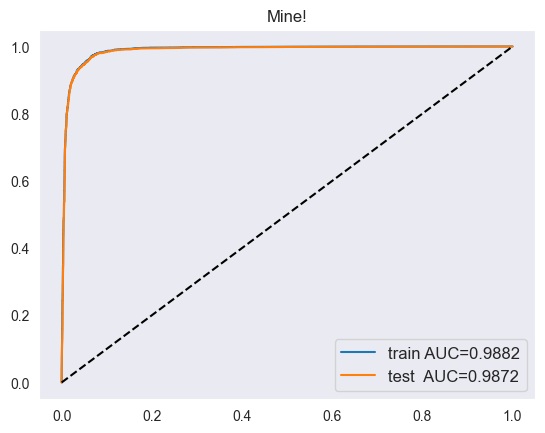

In [46]:
# обучение на ваших признаках

#Тут будем использовать полученные выше лучшие параметры

bpe_tokenizer = BPETokenizer(vocab_size=800)
full_text = " ".join(train_data["Comment"].astype(str).str.lower())
bpe_tokenizer.train(full_text)
train_data["tokens_bpe"] = [bpe_tokenizer.tokenize(text) for text in tqdm(train_data["Comment"].astype(str).str.lower())]
test_data["tokens_bpe"]  = [bpe_tokenizer.tokenize(text) for text in tqdm(test_data["Comment"].astype(str).str.lower())]

freq_all, freq_pos, freq_neg = count_tokens("tokens_bpe")
total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())
diffs_bpe = {t: abs(freq_pos.get(t,0)/total_pos - freq_neg.get(t,0)/total_neg) for t in set(freq_pos) | set(freq_neg)}


kw, kb = 450, 250
top_diff_word = sorted(diffs_word.items(), key=lambda x: x[1], reverse=True)[:kw]
top_diff_bpe  = sorted(diffs_bpe.items(),  key=lambda x: x[1], reverse=True)[:kb]

my_model = LogisticRegression(max_iter=1000)

train_combined = all_tok_features(train_data, [top_diff_word, top_diff_bpe], ['tokens_word', 'tokens_bpe'])
my_train = my_features(train_data).drop('label', axis=1)
train_combined = pd.concat([train_combined, my_train], axis=1)

test_combined = all_tok_features(test_data, [top_diff_word, top_diff_bpe], ['tokens_word', 'tokens_bpe'])
my_test = my_features(test_data).drop('label', axis=1)
test_combined = pd.concat([test_combined, my_test], axis=1)

train_and_predict(my_model, train_combined, test_combined, "Mine!")


**ВАША ИТОГОВАЯ ЦЕЛЬ — ПОБИТЬ ПОРОГ В `0.8 accuracy`**

**ВАШИ ИТОГОВЫЕ ВЫВОДЫ ПО ВСЕЙ РАБОТЕ**

**Word-level (accuracy 0.851):** Словесная токенизация ожидаемо показала хороший результат, т.к. слова напрямую несут смысл (и эмоции, соответственно).
Использование топ-100 токенов по разнице частот вместо топ-15 оказалось решающим. Порог преодолён.

**Char-level (accuracy 0.732):** Ожидаемо худший результат. Отдельные символы не несут смысловой нагрузки, разделить классы по буквенному составу практически
невозможно. До порога не дотянул.

**BPE (accuracy 0.789):** Лучше char, хуже word. "Подсловные" токены частично захватывают морфологию, но теряют контекст целого слова. Порог не преодолён.

**Объединённый набор (accuracy 0.877):** Комбинирование всех трёх токенизаций дало прирост. Значит, разные методы извлекают разные признаки. По моему мнению,
Char вносит шум, поэтому в итоговой "моей модели" я его убрал вовсе.

**Word + BPE + мои признаки (accuracy 0.95):** Лучший результат, порог преодолён с запасом. Исключение char-токенов, подбор оптимального размера словаря в BPE и количества топ-слов, плюс мои признаки (hate/love-слова, капслок, знаки препинания) сделали дело.

**Собственный вывод:** даже простые бинарные признаки наличия токена позволяют строить хорошие классификаторы (мне было это совсем неочевидно, я думал, мы с трансформерами будем работать в токенизации. круто.) Ключевую роль, очевидно, играет выбор токенизатора и отбор токенов с наибольшей "различающей силой". Фичи, отражающие стиль, тоже могут дать заметный прирост